In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))   # if notebook is in notebooks/

from src.config_loader import ConfigLoader
from src.signal_generator import Scenario, SignalGenerator
import matplotlib.pyplot as plt

loader = ConfigLoader("../config")
gen = SignalGenerator(loader)
scn = Scenario.from_yaml("../config/scenarios/city_drive.yaml")
df = gen.generate(scn)


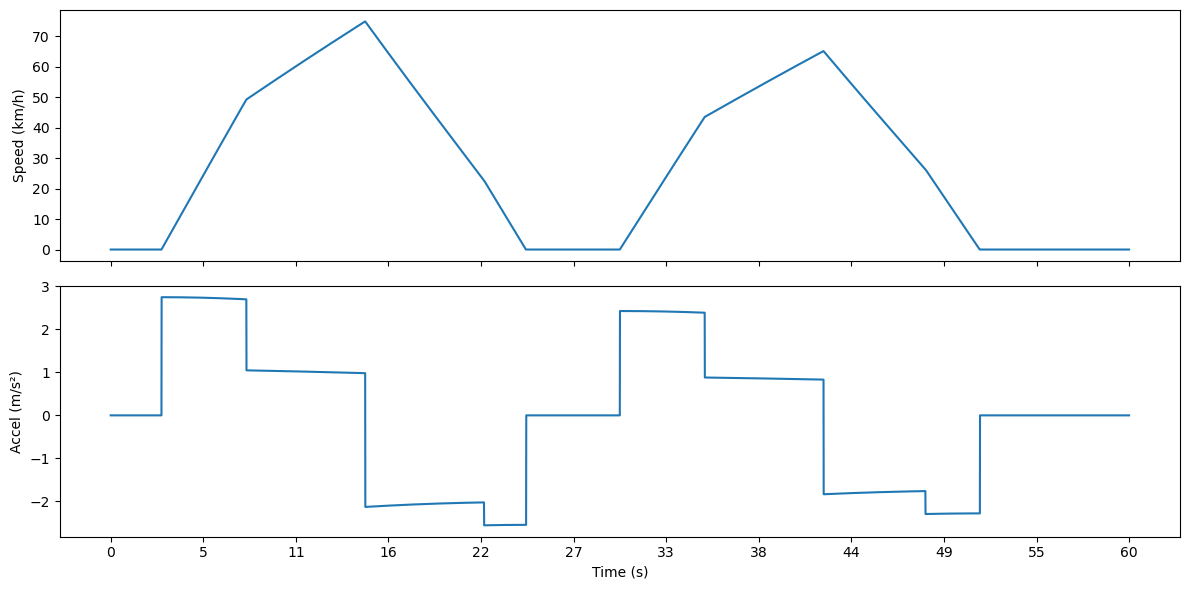

In [2]:
import numpy as np

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax[0].plot(df["time_s"], df["vehicle_speed"])
ax[0].set_ylabel("Speed (km/h)")

ax[1].plot(df["time_s"], df["longitudinal_acceleration"])
ax[1].set_ylabel("Accel (m/s²)")
ax[1].set_xlabel("Time (s)")

# Exactly 5 evenly spaced ticks, increasing order
ticks = np.linspace(df["time_s"].min(), df["time_s"].max(), 12)
ax[1].set_xticks(ticks)
ax[1].set_xticklabels([f"{t:.0f}" for t in ticks])

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Time (s)')

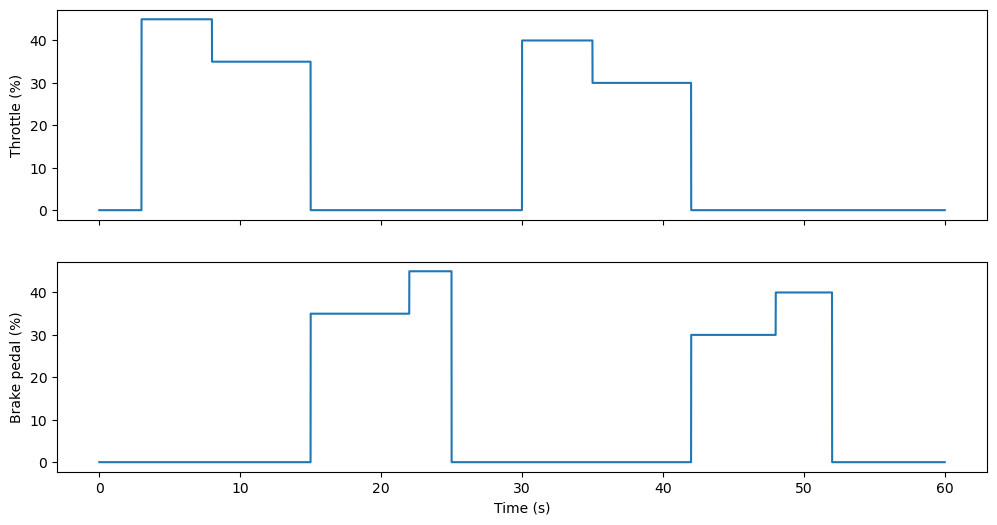

In [3]:
# Cell 3: Driver inputs
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(df["time_s"], df["throttle_position"])
ax[0].set_ylabel("Throttle (%)")
ax[1].plot(df["time_s"], df["brake_pedal"])
ax[1].set_ylabel("Brake pedal (%)")
ax[1].set_xlabel("Time (s)")

Text(0.5, 0, 'Time (s)')

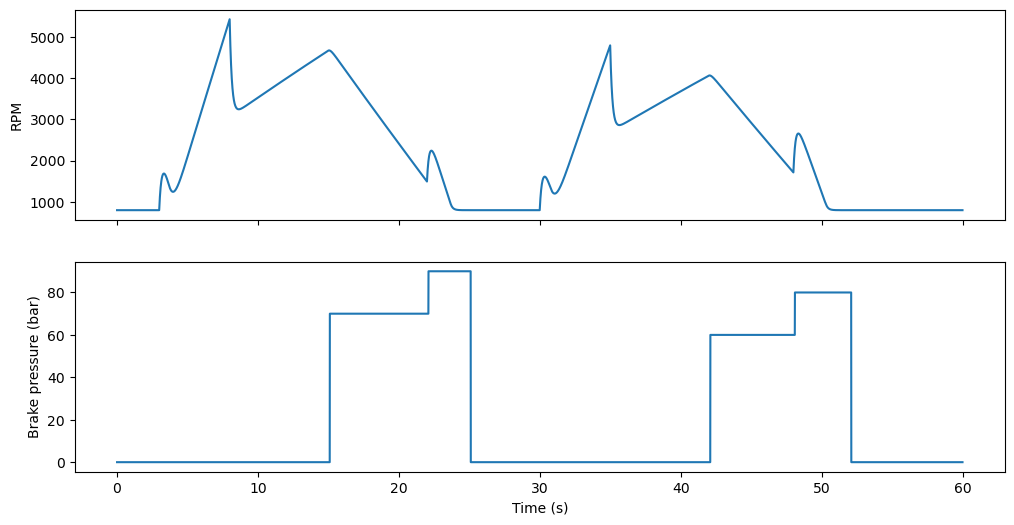

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(df["time_s"], df["engine_rpm"])
ax[0].set_ylabel("RPM")
ax[1].plot(df["time_s"], df["brake_pressure"])
ax[1].set_ylabel("Brake pressure (bar)")
ax[1].set_xlabel("Time (s)")


Text(0.5, 0, 'Time (s)')

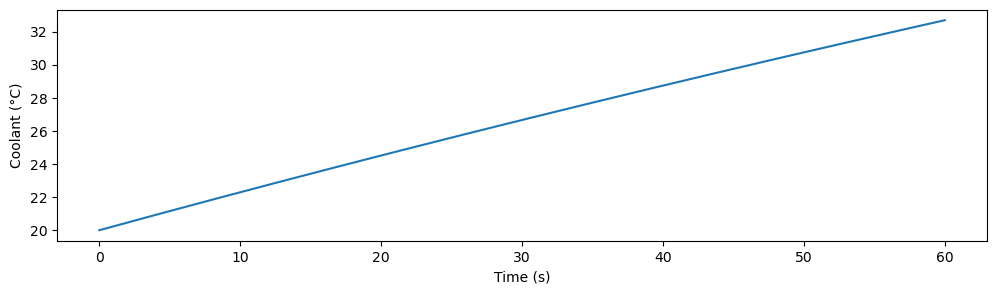

In [5]:
plt.figure(figsize=(12, 3))
plt.plot(df["time_s"], df["coolant_temperature"])
plt.ylabel("Coolant (°C)")
plt.xlabel("Time (s)")

In [6]:
print("Range checks:")
for name, spec in gen.signals.items():
    lo, hi = spec["range"]
    print(f"  {name:30s}: [{df[name].min():8.2f}, {df[name].max():8.2f}]  range={spec['range']}")


Range checks:
  engine_rpm                    : [  800.00,  5430.46]  range=[0, 8000]
  throttle_position             : [    0.00,    45.00]  range=[0, 100]
  coolant_temperature           : [   20.00,    32.69]  range=[-40, 150]
  brake_pressure                : [    0.00,    90.00]  range=[0, 200]
  brake_pedal                   : [    0.00,    45.00]  range=[0, 100]
  wheel_speed                   : [    0.00,    74.79]  range=[0, 250]
  vehicle_speed                 : [    0.00,    74.79]  range=[0, 250]
  longitudinal_acceleration     : [   -2.56,     2.75]  range=[-10, 5]


In [7]:
# Cell 0: Define helper — one subplot per signal
import matplotlib.pyplot as plt
from src.config_loader import ConfigLoader
from src.signal_generator import Scenario, SignalGenerator

def plot_scenario(gen, systems, scenario_path):
    """Load a scenario, generate signals, and plot each signal on its own subplot."""
    scenario = Scenario.from_yaml(scenario_path)
    df = gen.generate(scenario)

    # Order signals: driver inputs first, then by system
    signal_order = ["throttle_position", "brake_pedal", "gear"]
    for sys_name, sys_spec in systems.items():
        for sig in sys_spec["signals"]:
            if sig not in signal_order:
                signal_order.append(sig)

    # Keep only signals that exist in the DataFrame
    signal_order = [s for s in signal_order if s in df.columns]

    n = len(signal_order)
    fig, axes = plt.subplots(
        n, 1,
        figsize=(13, 2.2 * n),
        sharex=True,
    )
    if n == 1:
        axes = [axes]

    for ax, sig in zip(axes, signal_order):
        spec = gen.signals.get(sig, {})
        unit = spec.get("unit", "")
        rng = spec.get("range", None)

        ax.plot(df["time_s"], df[sig], linewidth=1.5, color="tab:blue")
        ax.set_ylabel(f"{sig}\n({unit})" if unit else sig, fontsize=9)
        ax.grid(alpha=0.3)

        if rng is not None:
            ax.set_ylim(rng[0], rng[1])
            ax.axhline(rng[0], color="gray", linewidth=0.5, linestyle="--", alpha=0.5)
            ax.axhline(rng[1], color="gray", linewidth=0.5, linestyle="--", alpha=0.5)

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(
        f"Scenario: {scenario.name}  |  Vehicle: {scenario.vehicle_id}",
        fontsize=13, fontweight="bold", y=0.998,
    )
    plt.tight_layout()
    plt.show()
    return df

In [8]:

loader = ConfigLoader("../config")
gen = SignalGenerator(loader)
systems = loader.load_systems()


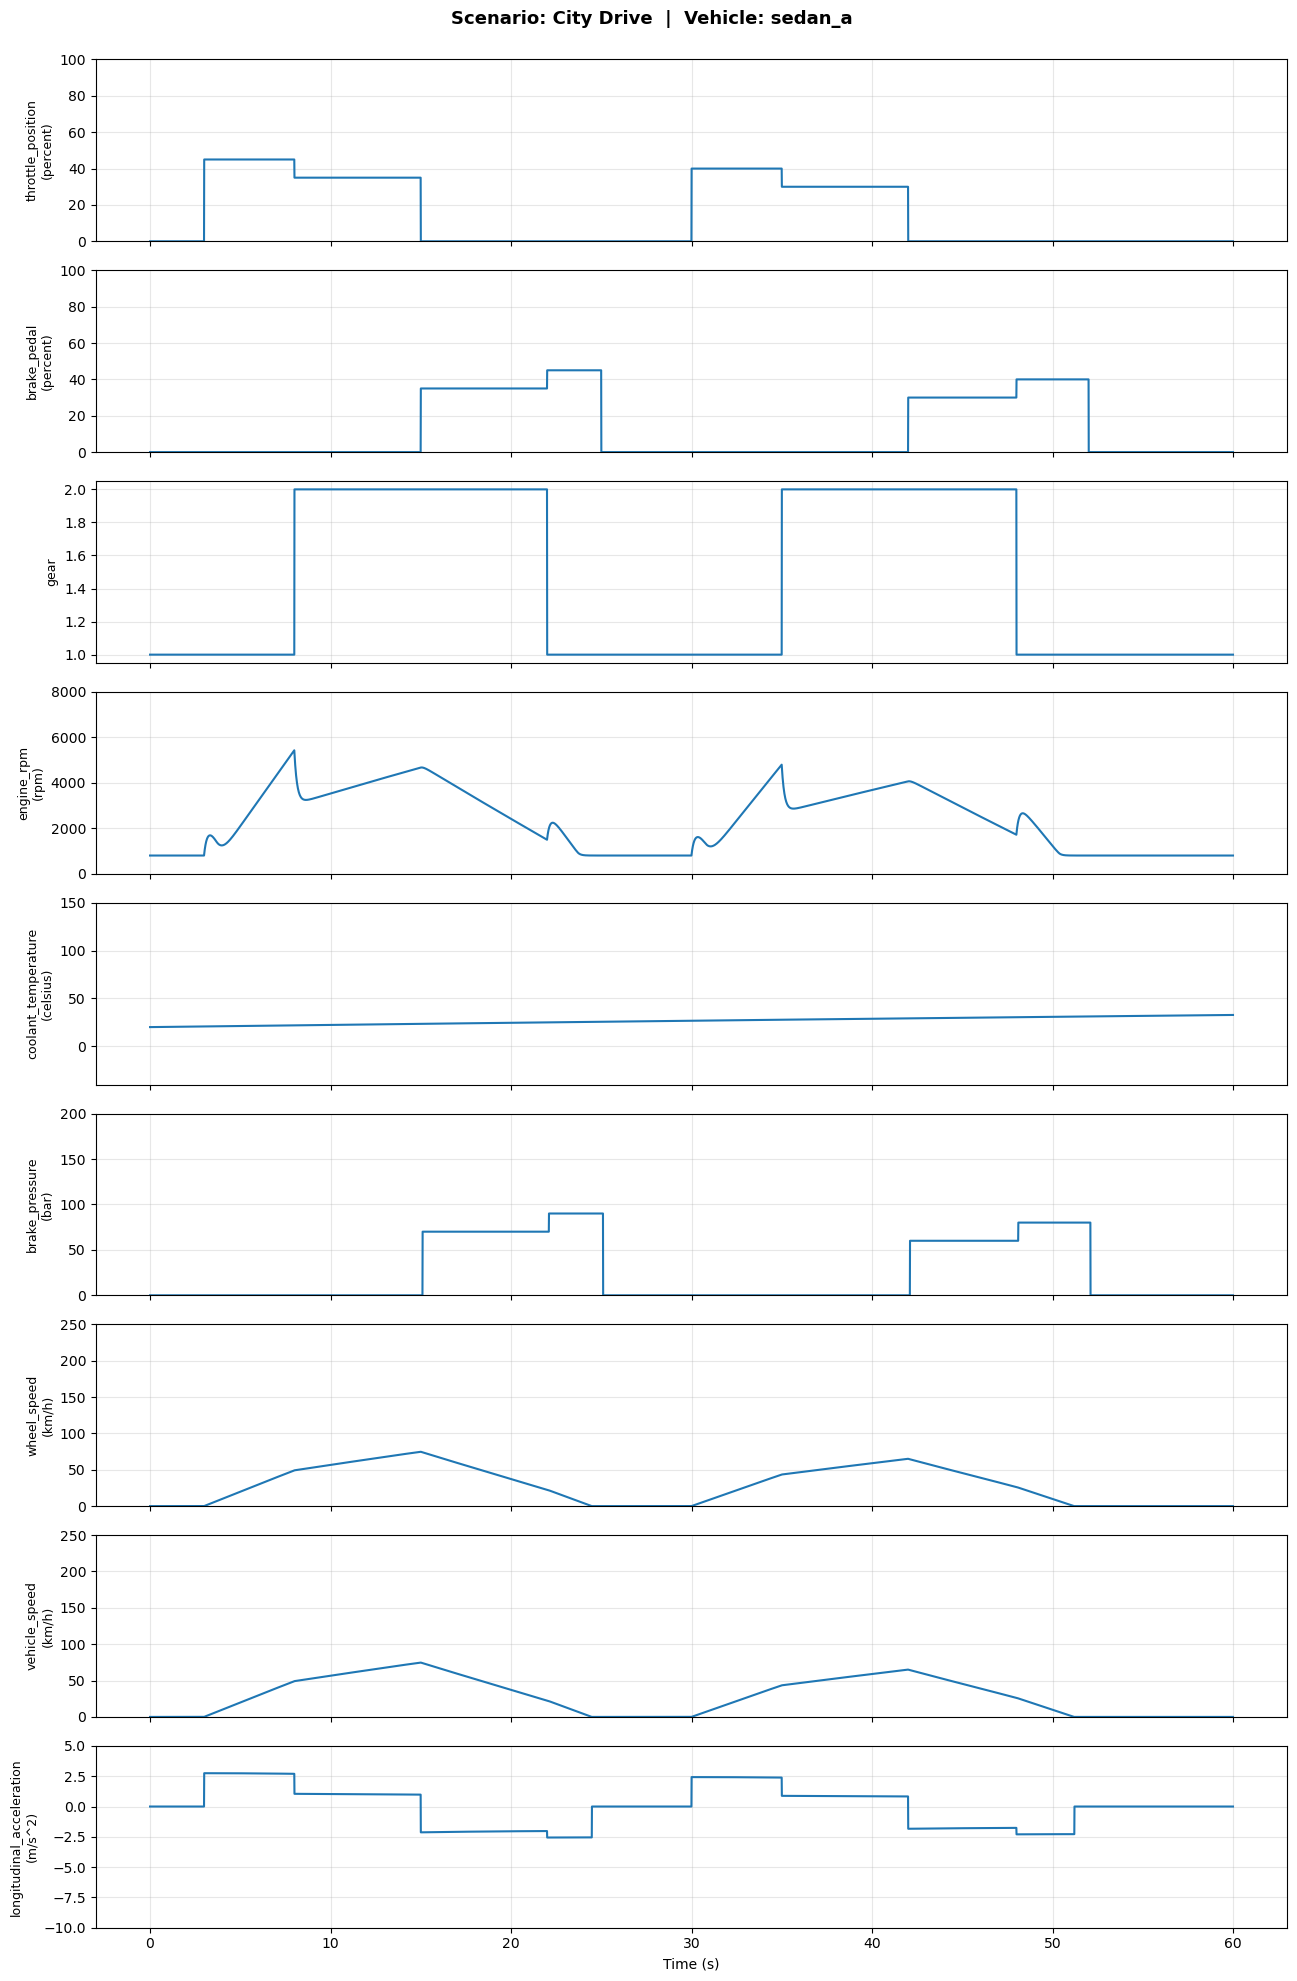

In [9]:


df_city = plot_scenario(gen, systems, "../config/scenarios/city_drive.yaml")


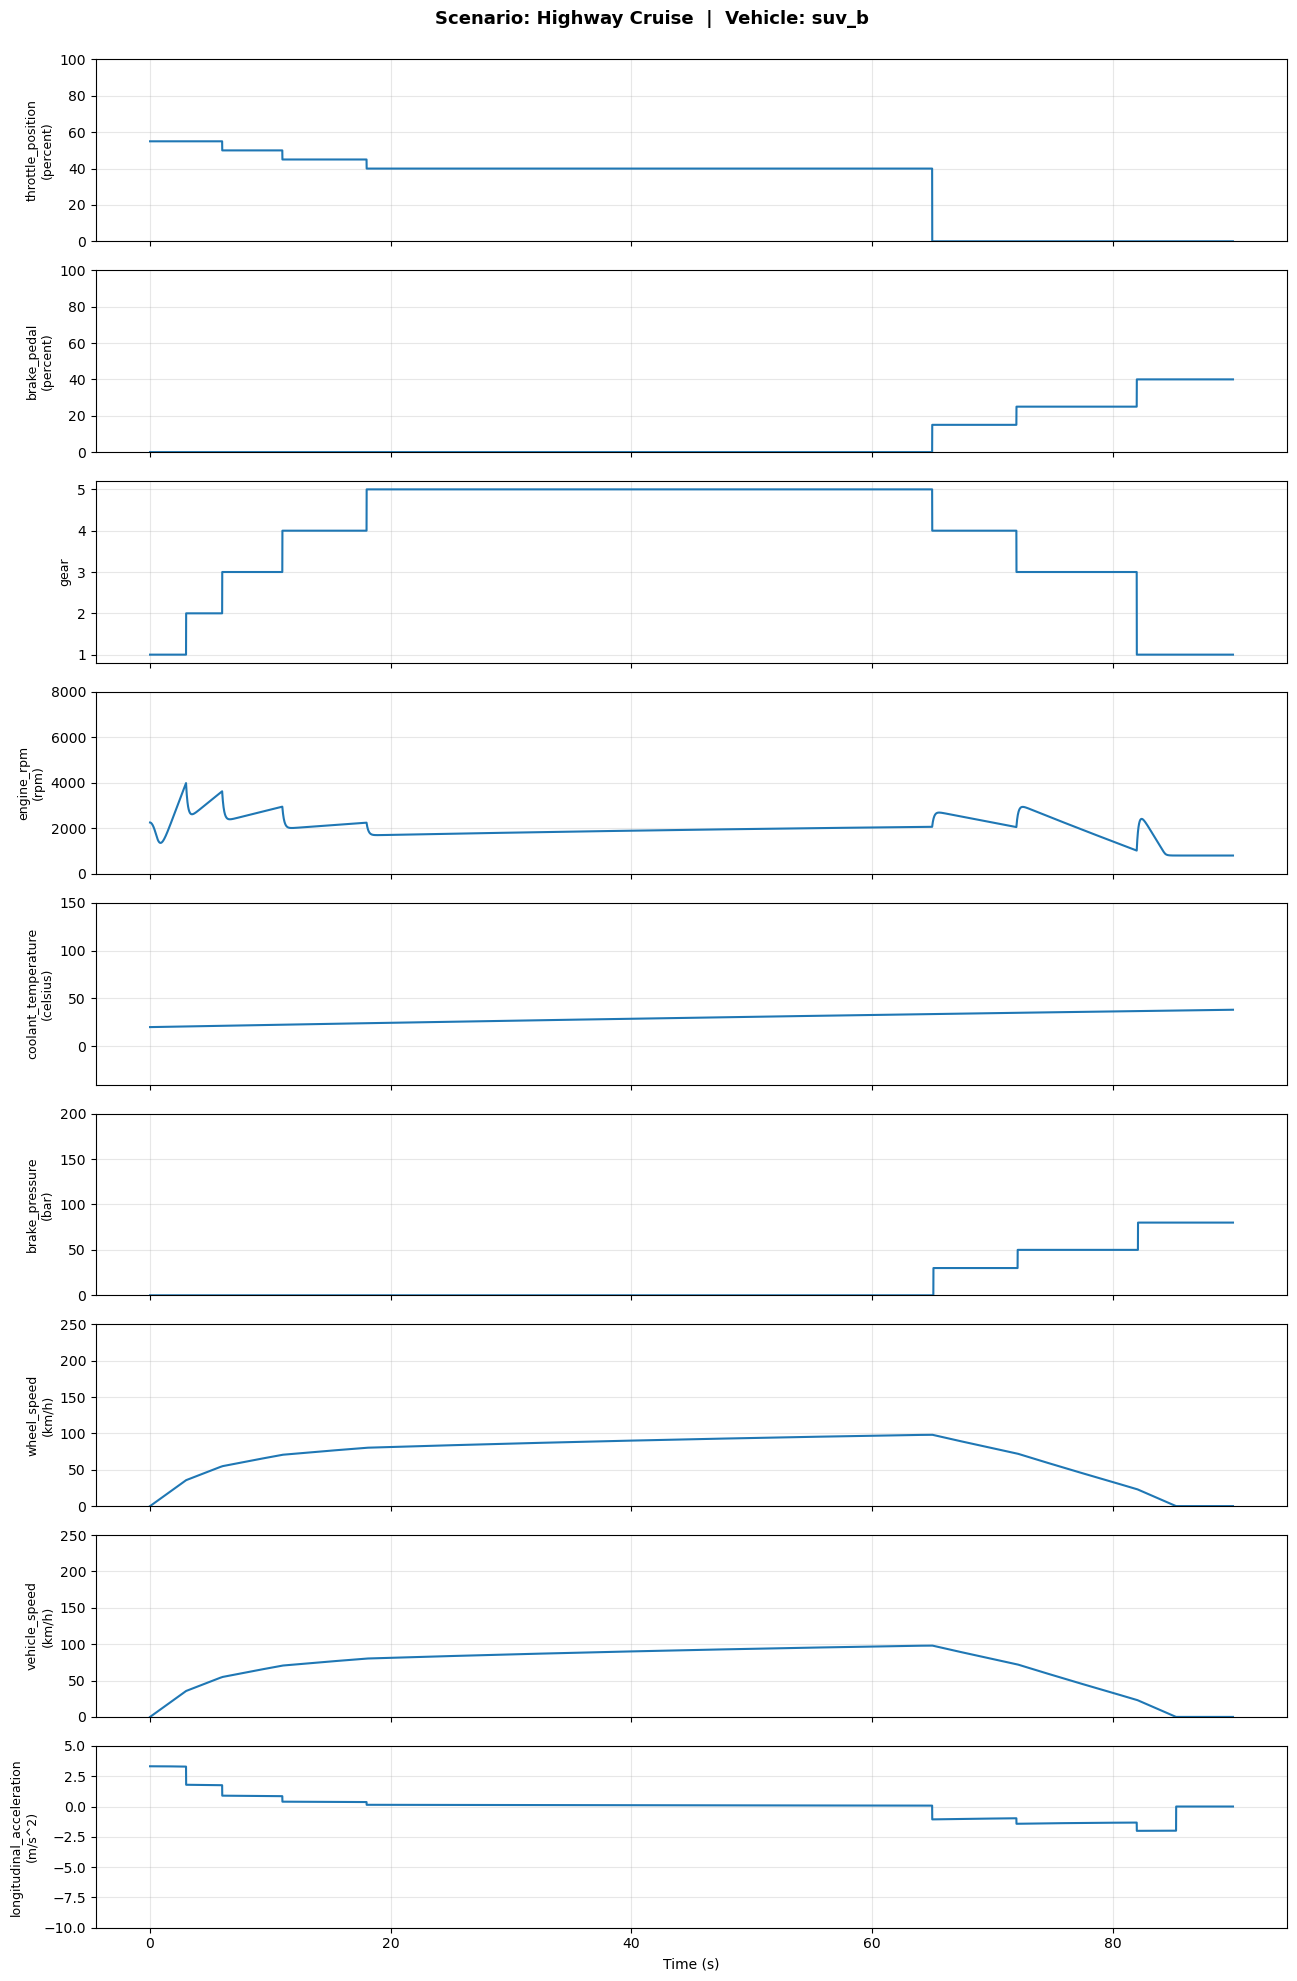

In [10]:

df_hw = plot_scenario(gen, systems, "../config/scenarios/highway_cruise.yaml")

In [11]:
# Diagnostic cell — compare Phase 2 speed vs. final speed
import numpy as np
from src.config_loader import ConfigLoader
from src.signal_generator import Scenario, SignalGenerator

loader = ConfigLoader("../config")
gen = SignalGenerator(loader)

scenario = Scenario.from_yaml("../config/scenarios/highway_cruise.yaml")
vehicle = loader.load_vehicles()[scenario.vehicle_id]

# Run Phase 1 and 2 manually
dt = 1.0 / scenario.base_rate_hz
n_steps = int(round(scenario.duration_s * scenario.base_rate_hz))
driver = gen._build_driver_inputs(scenario, n_steps, dt)
dynamics = gen._compute_dynamics(driver, vehicle, dt)

print("Phase 2 speed max (km/h):", dynamics["vehicle_speed"].max())
print("Phase 2 speed at t=18:", dynamics["vehicle_speed"][1800])
print("Phase 2 speed at t=65:", dynamics["vehicle_speed"][6500])

# Now run Phase 3
df = gen.generate(scenario)
print()
print("Final speed max (km/h):", df["vehicle_speed"].max())
print("Final speed at t=18:", df.loc[df["time_s"] == 18.0, "vehicle_speed"].iloc[0])
print("Final speed at t=65:", df.loc[df["time_s"] == 65.0, "vehicle_speed"].iloc[0])

# Compare
print()
print("Phase 2 vs Phase 3 mismatch at t=18?",
      abs(dynamics["vehicle_speed"][1800] - df.loc[df["time_s"] == 18.0, "vehicle_speed"].iloc[0]))

Phase 2 speed max (km/h): 98.17526591024507
Phase 2 speed at t=18: 80.28604688029712
Phase 2 speed at t=65: 98.1370587281016

Final speed max (km/h): 98.17526591024507
Final speed at t=18: 80.28604688029712
Final speed at t=65: 98.1370587281016

Phase 2 vs Phase 3 mismatch at t=18? 0.0
